<a href="https://colab.research.google.com/github/ayse50/PyTorch/blob/main/casting_product.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Qualitätskontrolle von Gussteilen

### Problem
 Die manuelle Inspektion von Gussteilen ist zeitaufwendig, fehleranfällig und führt durch menschliche Ungenauigkeit zu wirtschaftlichen Verlusten.


### Lösung
Entwicklung eines Deep Learning Modells zu binären Klassifikation mithilfe von PyTorch, um die Inspektionsprozesse zu automatisieren und somit zu erleichtern.


### Datensatz
*   Inhalt: Graustufenbilder von Pumpen-Impellern
*   Klassen: 2 (Defekt vs. Ok)





## 1. Daten Laden und Visualisieren

### Daten von Kaggle laden

In [6]:
!pip install opendatasets --upgrade --quiet

In [7]:

import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product'
od.download(dataset_url)


Skipping, found downloaded files in "./real-life-industrial-dataset-of-casting-product" (use force=True to force download)


### Pfade zu den bereits existierenden Datensets festlegen

In [8]:
import os

base_path = '/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data'
train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
train_ok_dir = os.path.join(train_dir, 'ok_front' )
train_def_dir = os.path.join(train_dir, 'def_front' )
test_ok_dir = os.path.join(test_dir, 'ok_front' )
test_def_dir = os.path.join(test_dir, 'def_front' )


### Visualisierung der Datenaufteilung

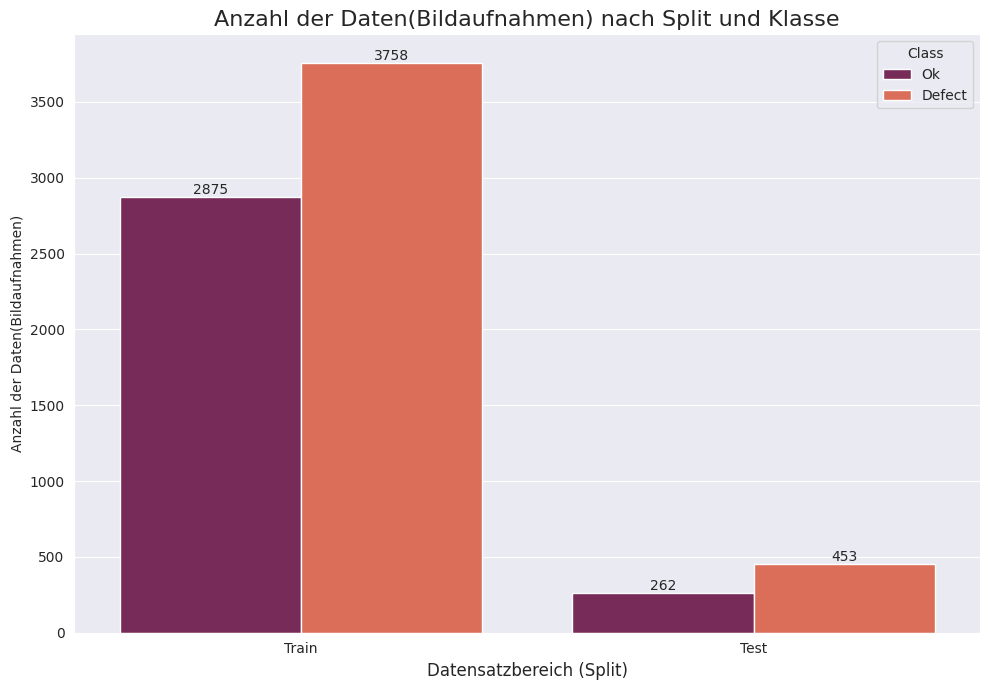

In [16]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Zählen der Daten
train_def = len(os.listdir(train_def_dir))
train_ok = len(os.listdir(train_ok_dir))
test_def = len(os.listdir(test_def_dir))
test_ok = len(os.listdir(test_ok_dir))

# Erstellen eines Dataframes  mit den Test und train daten
daten = {'Teilung': ['Train', 'Train', 'Test', 'Test'],
         'Class': ['Ok', 'Defect', 'Ok', 'Defect'],
         'Anzahl': [train_ok, train_def, test_ok, test_def]}

df = pd.DataFrame(daten)

#Visualisierung der Aufteilung der Daten
sns.set_style('darkgrid')
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Teilung', y='Anzahl', hue='Class', data=df, palette="rocket")
plt.title('Anzahl der Daten(Bildaufnahmen) nach Split und Klasse', fontsize=16)
plt.xlabel('Datensatzbereich (Split)', fontsize=12)
plt.ylabel('Anzahl der Daten(Bildaufnahmen)')

for container in ax.containers:
  ax.bar_label(container)

plt.tight_layout()
plt.show()


In [15]:
print(f'Verhältnis im Training:{train_ok / train_def:.2f} (Ok zu Defekt)')
print(f'Verhältnis im Test:{test_ok / test_def:.2f} (Ok zu Defekt)')

Verhältnis im Training:0.77 (Ok zu Defekt)
Verhältnis im Test:0.58 (Ok zu Defekt)


### Verhältnisse in den Sets sind recht ausgewogen.

## 2. Daten vorbereiten

In [107]:
import torch
import torchvision
from torchvision import transforms, datasets
from torchvision.transforms import ToTensor
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import numpy as np

SEED = 42
torch.manual_seed(SEED)

#Bilder in Tensor umwandeln und normalisieren
transform_img_trn = transforms.Compose([transforms.Resize((224, 224)),
                                        transforms.Grayscale(num_output_channels=1),
                                        transforms.RandomRotation(15),
                                        transforms.RandomHorizontalFlip(),
                                        transforms.RandomVerticalFlip(),
                                        transforms.ColorJitter(brightness=0.3, contrast=0.3),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.5], std=[0.5])])

transform_img_tst = transforms.Compose([transforms.Resize((224, 224)),
                                        transforms.Grayscale(num_output_channels=1),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.5], std=[0.5])])

train_set = datasets.ImageFolder(root='/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train', transform=transform_img_trn)
test_set =datasets.ImageFolder(root='/content/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test', transform=transform_img_tst)

#Dataloader
BATCH_SIZE = 32

train_dataloader= DataLoader(train_set,
                             batch_size=BATCH_SIZE,
                             shuffle = True)


test_dataloader= DataLoader(test_set,
                             batch_size=BATCH_SIZE,
                             shuffle = False)


print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7bca604b30e0>, <torch.utils.data.dataloader.DataLoader object at 0x7bca4789c680>)
Length of train dataloader: 208 batches of 32
Length of test dataloader: 23 batches of 32


In [108]:
images, labels = next(iter(train_dataloader))
class_names = train_set.classes
images.shape, labels.shape

(torch.Size([32, 1, 224, 224]), torch.Size([32]))

### Anzeigen von 4 zufälligen Bildern aus dem Trainingsset (4 Sample)
#### es dient für die Kontrolle, ob auch die Daten unverändert bleiben.


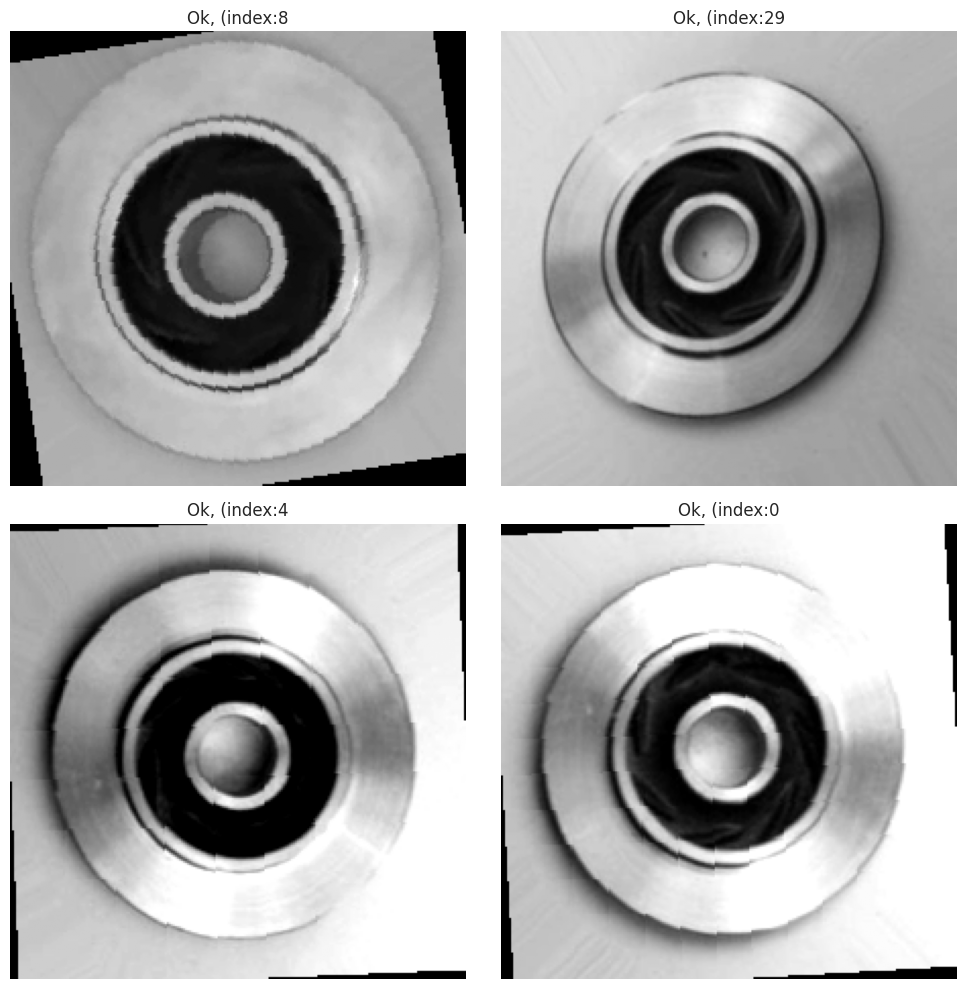

In [109]:

fig, axes = plt.subplots(2,2, figsize=(10,10))
random_idx = torch.randint(0, len(images), size=[4])
axes = axes.flatten()

for i, idx in enumerate(random_idx):
  img = images[idx]
  label = labels[idx].item()

  name = class_names[label]
  if 'ok' in name.lower():
    uberschrift = 'Ok'
  else:
    uberschrift = 'Defekt'

  axes[i].imshow(img.squeeze(), cmap=('gray'))
  axes[i].set_title(f'{uberschrift}, (index:{idx.item()}')
  axes[i].axis('off')

plt.tight_layout()
plt.show()

## 3. Model, Loss Funktion und Optimizer

Zuerst ein Baseline Model aufbauen um weitere Modelle damit vergleichen zu können.

Für Baseline Model das simpelste nehmen: --> Mein Baseline Modell besteht aus zwei nn.Linear() Layern.

In [112]:
import torch
from torch import nn

# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else'cpu'


flatten_model = nn.Flatten()
x = images[0]
output = flatten_model(x)

print(f'Form bevor flattening: {x.shape}')
print(f'Form nach flattening: {output.shape}')


Form bevor flattening: torch.Size([1, 224, 224])
Form nach flattening: torch.Size([1, 50176])


In [111]:
class ModelV0(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatter(),
        nn.Linear(in_features=input_shape, out_features=hidden_units),
        nn.Linear(in_features=input_shape, out_features=hidden_units)
    )

def forward(self, x):
  return self.layer_stack(x)



